**© Copyright AIDENTIFY. All rights reserved.**

# Part 2 | Session 14: Next Token Prediction 기반 SFT 실습

**Part 3: 파인튜닝 기초** | GPU: Yes (RTX 4060 8GB)

---

### 📋 학습 목표
- 🎯 Next Token Prediction(NTP)의 원리를 이해하고 직접 실험한다
- 🎯 HuggingFace Trainer API와 SFTTrainer의 사용법을 익힌다
- 🎯 Qwen2.5-1.5B 모델을 LoRA로 파인튜닝한다
- 🎯 학습 전후 모델의 응답을 비교한다

### ⏱️ 예상 소요 시간: 120분

### 🖥️ 요구 사양
- GPU: RTX 4060 (8GB VRAM) 이상
- 모델: Qwen2.5-1.5B-Instruct
- 설정: batch_size=1, gradient_accumulation=8, fp16=True, max_seq_length=1024

In [1]:
# 환경 설정 및 GPU 확인
import torch
import gc
import os
import json
import time

# GPU 메모리 모니터링 함수
def print_gpu_memory(tag=""):
    if torch.cuda.is_available():
        allocated = torch.cuda.memory_allocated() / 1024**3
        total = torch.cuda.get_device_properties(0).total_memory / 1024**3
        print(f"[{tag}] GPU: {allocated:.1f}GB / {total:.1f}GB")

print("✅ Session 14: Next Token Prediction 기반 SFT 실습")
print("=" * 60)

# GPU 확인
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    vram = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"✅ GPU: {gpu_name} ({vram:.1f}GB VRAM)")
    print_gpu_memory("초기 상태")
else:
    print("❌ GPU를 사용할 수 없습니다!")
    print("   이 노트북은 GPU가 필수입니다.")

print(f"✅ PyTorch: {torch.__version__}")
print(f"✅ CUDA: {torch.version.cuda}")

✅ Session 14: Next Token Prediction 기반 SFT 실습
✅ GPU: NVIDIA GeForce RTX 3070 (7.6GB VRAM)
[초기 상태] GPU: 0.0GB / 7.6GB
✅ PyTorch: 2.11.0+cu128
✅ CUDA: 12.8


In [2]:
# 필수 라이브러리 확인
print("📦 필수 라이브러리 확인")
print("=" * 60)

required = {
    "transformers": "transformers",
    "peft": "peft",
    "trl": "trl",
    "datasets": "datasets",
    "accelerate": "accelerate",
    "bitsandbytes": "bitsandbytes",
}

for name, pkg in required.items():
    try:
        module = __import__(pkg)
        version = getattr(module, '__version__', 'unknown')
        print(f"  ✅ {name}: {version}")
    except ImportError:
        print(f"  ❌ {name}: 설치 필요 (pip install {pkg})")

📦 필수 라이브러리 확인


/home/hpe/LLM_master_5parts/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  ✅ transformers: 4.57.2


Failed to load /home/hpe/LLM_master_5parts/venv/lib/python3.11/site-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so: Could not load this library: /home/hpe/LLM_master_5parts/venv/lib/python3.11/site-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so
Failed to load /home/hpe/LLM_master_5parts/venv/lib/python3.11/site-packages/torchao/_C_cutlass_90a.abi3.so: Could not load this library: /home/hpe/LLM_master_5parts/venv/lib/python3.11/site-packages/torchao/_C_cutlass_90a.abi3.so


  ✅ peft: 0.18.1
  ✅ trl: 0.23.0
  ✅ datasets: 4.3.0
  ✅ accelerate: 1.13.0
  ✅ bitsandbytes: 0.49.2


---
## 🎯 1. Next Token Prediction과 SFT

### NTP (Next Token Prediction)란?

모든 LLM의 핵심 학습 원리는 **다음 토큰 예측**입니다.

```
입력: "오늘 날씨가 정말"
예측: "좋" (다음 토큰)

입력: "오늘 날씨가 정말 좋"
예측: "다" (다음 토큰)
```

### SFT에서의 NTP

SFT에서는 **assistant의 응답 부분만** NTP 손실을 계산합니다.

```
[User] 파이썬의 장점을 설명하세요.     ← 손실 계산 안함 (마스킹)
[Assistant] 파이썬의 주요 장점은...     ← 손실 계산 O (학습 대상)
```

이것이 **Causal Language Modeling** 기반의 SFT입니다.

---
## 1️⃣ 2. 언어 모델의 학습 원리 (NTP)

In [3]:
# NTP 원리 실습 - 토큰화와 확률 분포
print("🔬 NTP 원리 실습: 토큰화와 다음 토큰 예측")
print("=" * 60)

from transformers import AutoTokenizer

# 토크나이저 로드
MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"
print(f"📌 모델: {MODEL_NAME}")
print(f"📌 토크나이저 로드 중...")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)

# 토큰화 예시
text = "오늘 날씨가 정말 좋습니다."
tokens = tokenizer.tokenize(text)
token_ids = tokenizer.encode(text)

print(f"\n📋 토큰화 예시:")
print(f"  원문: {text}")
print(f"  토큰: {tokens}")
print(f"  토큰 ID: {token_ids}")
print(f"  토큰 수: {len(tokens)}")

# NTP 학습 원리 시각화
print(f"\n📊 NTP 학습 시의 입력-타겟 쌍:")
print(f"  {'Step':>5s} | {'입력 (Input)':>30s} | {'타겟 (Target)':>15s}")
print(f"  {'-'*55}")

for i in range(min(len(tokens)-1, 6)):
    input_tokens = ' '.join(tokens[:i+1])
    target_token = tokens[i+1] if i+1 < len(tokens) else '[END]'
    print(f"  {i+1:>5d} | {input_tokens:>30s} | {target_token:>15s}")

print(f"\n💡 모델은 각 위치에서 다음 토큰을 예측하도록 학습됩니다.")
print(f"   어휘 크기: {tokenizer.vocab_size:,} (이 중 하나를 선택)")

🔬 NTP 원리 실습: 토큰화와 다음 토큰 예측
📌 모델: Qwen/Qwen2.5-1.5B-Instruct
📌 토크나이저 로드 중...

📋 토큰화 예시:
  원문: 오늘 날씨가 정말 좋습니다.
  토큰: ['ìĺ¤', 'ëĬĺ', 'ĠëĤ', 'ł', 'ìĶ¨', 'ê°Ģ', 'Ġìłķë§Ĳ', 'Ġì¢ĭ', 'ìĬµëĭĪëĭ¤', '.']
  토큰 ID: [57268, 127478, 37195, 254, 135562, 19969, 134247, 125953, 38231, 13]
  토큰 수: 10

📊 NTP 학습 시의 입력-타겟 쌍:
   Step |                     입력 (Input) |     타겟 (Target)
  -------------------------------------------------------
      1 |                            ìĺ¤ |             ëĬĺ
      2 |                        ìĺ¤ ëĬĺ |             ĠëĤ
      3 |                    ìĺ¤ ëĬĺ ĠëĤ |               ł
      4 |                  ìĺ¤ ëĬĺ ĠëĤ ł |             ìĶ¨
      5 |              ìĺ¤ ëĬĺ ĠëĤ ł ìĶ¨ |             ê°Ģ
      6 |          ìĺ¤ ëĬĺ ĠëĤ ł ìĶ¨ ê°Ģ |         Ġìłķë§Ĳ

💡 모델은 각 위치에서 다음 토큰을 예측하도록 학습됩니다.
   어휘 크기: 151,643 (이 중 하나를 선택)


---
## 2️⃣ 3. Causal Language Modeling 실습

In [4]:
# 모델 로드 및 NTP 실습
print("🧠 모델 로드: Qwen2.5-1.5B-Instruct")
print("=" * 60)

from transformers import AutoModelForCausalLM

# 모델 로드 (fp16으로 메모리 절약)
print("📌 모델 로드 중... (약 1-2분 소요)")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True,
)

print(f"\n✅ 모델 로드 완료!")
print(f"   파라미터 수: {sum(p.numel() for p in model.parameters()):,}")
print(f"   모델 크기: {sum(p.numel() * p.element_size() for p in model.parameters()) / 1024**3:.1f}GB")
print_gpu_memory("모델 로드 후")

🧠 모델 로드: Qwen2.5-1.5B-Instruct
📌 모델 로드 중... (약 1-2분 소요)


`torch_dtype` is deprecated! Use `dtype` instead!



✅ 모델 로드 완료!
   파라미터 수: 1,543,714,304
   모델 크기: 2.9GB
[모델 로드 후] GPU: 2.9GB / 7.6GB


In [5]:
# NTP 확률 분포 확인
print("🔬 다음 토큰 예측 확률 분포 확인")
print("=" * 60)

text = "인공지능의 미래는"
inputs = tokenizer(text, return_tensors="pt").to(model.device)

with torch.no_grad():
    outputs = model(**inputs)
    # 마지막 토큰의 logits
    last_logits = outputs.logits[0, -1, :]
    probs = torch.softmax(last_logits, dim=0)

# Top-10 예측 토큰
top_k = 10
top_probs, top_indices = torch.topk(probs, top_k)

print(f"입력: \"{text}\"")
print(f"\n📊 다음 토큰 예측 Top-{top_k}:")
print(f"  {'순위':>4s} | {'토큰':>15s} | {'확률':>10s} | {'시각화'}")
print(f"  {'-'*55}")

for rank, (prob, idx) in enumerate(zip(top_probs, top_indices), 1):
    token = tokenizer.decode(idx)
    bar = "█" * int(prob.item() * 100)
    print(f"  {rank:>4d} | {token:>15s} | {prob.item():>9.4f} | {bar}")

print(f"\n💡 모델이 가장 높은 확률로 예측한 다음 토큰: \"{tokenizer.decode(top_indices[0])}\"")
print(f"   → \"{text}{tokenizer.decode(top_indices[0])}\"")

🔬 다음 토큰 예측 확률 분포 확인
입력: "인공지능의 미래는"

📊 다음 토큰 예측 Top-10:
    순위 |              토큰 |         확률 | 시각화
  -------------------------------------------------------
     1 |              무엇 |    0.1527 | ███████████████
     2 |             어떻게 |    0.1074 | ██████████
     3 |               ? |    0.0602 | ██████
     4 |               � |    0.0508 | █████
     5 |              어디 |    0.0451 | ████
     6 |              어떤 |    0.0343 | ███
     7 |               ' |    0.0231 | ██
     8 |              AI |    0.0227 | ██
     9 |               � |    0.0191 | █
    10 |               인 |    0.0152 | █

💡 모델이 가장 높은 확률로 예측한 다음 토큰: " 무엇"
   → "인공지능의 미래는 무엇"


In [6]:
# SFT 전 기본 응답 확인 (Before)
print("📋 파인튜닝 전(Before) 모델 응답 확인")
print("=" * 60)

def generate_response(model, tokenizer, prompt, max_new_tokens=256):
    """모델로부터 응답 생성"""
    messages = [
        {"role": "system", "content": "당신은 유용한 한국어 AI 어시스턴트입니다."},
        {"role": "user", "content": prompt}
    ]
    
    text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = tokenizer(text, return_tensors="pt").to(model.device)
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.7,
            top_p=0.9,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id,
        )
    
    response = tokenizer.decode(
        outputs[0][inputs['input_ids'].shape[1]:], 
        skip_special_tokens=True
    )
    return response

# 테스트 질문들
test_prompts = [
"김의중을 소개하는 짧은 강사 프로필을 작성해주세요.",
"김의중 강사는 어떤 GPU로 실습을 진행하나요?",
"'LLM 마스터 5파트'는 무엇인가요?",
]

# Before 응답 저장
before_responses = {}

for i, prompt in enumerate(test_prompts, 1):
    print(f"\n{'─'*60}")
    print(f"📌 질문 {i}: {prompt}")
    print(f"{'─'*60}")
    
    response = generate_response(model, tokenizer, prompt)
    before_responses[prompt] = response
    print(f"🤖 응답:\n{response[:500]}")

print(f"\n✅ Before 응답 {len(before_responses)}개 저장 완료")
print_gpu_memory("추론 후")

📋 파인튜닝 전(Before) 모델 응답 확인

────────────────────────────────────────────────────────────
📌 질문 1: 김의중을 소개하는 짧은 강사 프로필을 작성해주세요.
────────────────────────────────────────────────────────────
🤖 응답:
김의중 (이름: 김의중)은 인공지능 기술과 언어 처리에 특화된 전문가입니다. 그는 현재 서울대학교에서 인공지능 및 자연어 처리 분야를 연구하고 있으며, 다양한 학위 과정을 통해 지식을 확장하고 있습니다.

김의중은 한국어와 영어 등 여러 언어를 이해하고 사용할 수 있는 능력을 가지고 있습니다. 이는 한국어 발음 훈련과 자주 활용되는 문맥에 대한 깊은 이해 덕분입니다. 또한, 김의중은 한국어와 영어 간의 번역 서비스를 제공하며, 이를 위해 업데이트된 사전 데이터베이스를 유지하고 있습니다.

그는 여러 기업과 연구소에서의 연구 참여도 하고 있으며, 특히 인공지능과 언어 처리 분야에서 높은 평가를 받고 있습니다. 김의중은 개인적으로도 많은 활동을 통해 자신의 기술과 경험을 공유하고 있습니다. 

김의중은 한국어 언어 처리와 인공지능 분야에서 전문가로서 인정받고 있으며, 앞으로도 새로운 기

────────────────────────────────────────────────────────────
📌 질문 2: 김의중 강사는 어떤 GPU로 실습을 진행하나요?
────────────────────────────────────────────────────────────
🤖 응답:
죄송합니다, 저는 인공지능으로서 개인적인 경험이나 지식을 가지고 있지 않습니다. 하지만 김의중 교수님이 사용하는 GPU에 대한 정보를 제공해 드릴 수는 없네요. 이에 대해 더 자세히 알고 싶으시다면, 해당 학교나 연구소의 공식 웹사이트나 이메일로 문의하시는 것이 좋겠습니다.

─────────────────────────────────────────────

---
## 3️⃣ 4. Trainer API 소개 (TrainingArguments, Trainer)

In [7]:
# TrainingArguments 설명
print("📚 TrainingArguments 핵심 파라미터 설명")
print("=" * 60)

training_args_explained = {
    "output_dir": {
        "설명": "학습 결과(체크포인트, 로그) 저장 경로",
        "RTX 4060 권장값": "'./output'",
    },
    "num_train_epochs": {
        "설명": "전체 데이터를 몇 번 반복 학습할지",
        "RTX 4060 권장값": "3 (과적합 주의)",
    },
    "per_device_train_batch_size": {
        "설명": "GPU당 한 번에 처리할 데이터 수",
        "RTX 4060 권장값": "1 (VRAM 제한)",
    },
    "gradient_accumulation_steps": {
        "설명": "가상 배치 크기 = batch_size × 이 값",
        "RTX 4060 권장값": "8 (effective batch=8)",
    },
    "learning_rate": {
        "설명": "학습률 (LoRA는 높게 설정 가능)",
        "RTX 4060 권장값": "2e-4",
    },
    "warmup_ratio": {
        "설명": "학습 초반 warmup 비율",
        "RTX 4060 권장값": "0.03",
    },
    "fp16": {
        "설명": "16bit 혼합 정밀도 학습",
        "RTX 4060 권장값": "True (VRAM 절약)",
    },
    "logging_steps": {
        "설명": "몇 스텝마다 로그 출력",
        "RTX 4060 권장값": "10",
    },
    "save_strategy": {
        "설명": "체크포인트 저장 전략",
        "RTX 4060 권장값": "'epoch'",
    },
    "optim": {
        "설명": "옵티마이저 종류",
        "RTX 4060 권장값": "'adamw_torch'",
    },
}

for param, info in training_args_explained.items():
    print(f"\n  📌 {param}")
    print(f"     설명: {info['설명']}")
    print(f"     권장: {info['RTX 4060 권장값']}")

📚 TrainingArguments 핵심 파라미터 설명

  📌 output_dir
     설명: 학습 결과(체크포인트, 로그) 저장 경로
     권장: './output'

  📌 num_train_epochs
     설명: 전체 데이터를 몇 번 반복 학습할지
     권장: 3 (과적합 주의)

  📌 per_device_train_batch_size
     설명: GPU당 한 번에 처리할 데이터 수
     권장: 1 (VRAM 제한)

  📌 gradient_accumulation_steps
     설명: 가상 배치 크기 = batch_size × 이 값
     권장: 8 (effective batch=8)

  📌 learning_rate
     설명: 학습률 (LoRA는 높게 설정 가능)
     권장: 2e-4

  📌 warmup_ratio
     설명: 학습 초반 warmup 비율
     권장: 0.03

  📌 fp16
     설명: 16bit 혼합 정밀도 학습
     권장: True (VRAM 절약)

  📌 logging_steps
     설명: 몇 스텝마다 로그 출력
     권장: 10

  📌 save_strategy
     설명: 체크포인트 저장 전략
     권장: 'epoch'

  📌 optim
     설명: 옵티마이저 종류
     권장: 'adamw_torch'


---
## 4️⃣ 5. SFTTrainer (trl 라이브러리) 소개

### SFTTrainer란?

HuggingFace의 `trl` 라이브러리에서 제공하는 **SFT 전용 Trainer**입니다.

```python
from trl import SFTTrainer, SFTConfig

# 기본 Trainer보다 간편한 SFT
trainer = SFTTrainer(
    model=model,
    args=sft_config,
    train_dataset=dataset,
    peft_config=lora_config,  # LoRA 설정 자동 적용
)
```

### SFTTrainer의 장점
- 📌 데이터 포맷팅 자동 처리 (ChatML 등)
- 📌 LoRA/QLoRA 통합 지원
- 📌 패킹(Packing) 지원 - 짧은 데이터 효율적 처리
- 📌 응답 부분만 loss 계산 가능

---
## 5️⃣ 6. 실습: Qwen2.5-1.5B로 간단한 SFT

In [8]:
# 학습 데이터 준비
print("📥 학습 데이터 준비")
print("=" * 60)

from datasets import Dataset

# 데이터 로드
DATA_DIR = os.path.join(os.path.dirname(os.getcwd()), "data", "samples")
data_file = os.path.join(DATA_DIR, "persona_ko_sample.json")

if os.path.exists(data_file):
    with open(data_file, 'r', encoding='utf-8') as f:
        raw_data = json.load(f)
    print(f"✅ 데이터 로드: {data_file} ({len(raw_data)}개)")
else:
    print(f"⚠️ 데이터 파일이 없습니다. 샘플 데이터를 생성합니다.")
    raw_data = [
        {"instruction": "다음 문장을 영어로 번역하세요.", "input": "오늘 날씨가 매우 좋습니다.", "output": "The weather is very nice today."},
        {"instruction": "다음 텍스트의 감성을 분석하세요.", "input": "이 영화는 정말 재미있었어요!", "output": "긍정적인 감성입니다."},
        {"instruction": "파이썬에서 리스트 컴프리헨션을 설명하세요.", "input": "", "output": "리스트 컴프리헨션은 [expression for item in iterable if condition] 형식으로 리스트를 간결하게 생성하는 방법입니다."},
        {"instruction": "머신러닝에서 과적합이란?", "input": "", "output": "과적합은 모델이 학습 데이터에 지나치게 맞춰져 새로운 데이터에 대한 성능이 떨어지는 현상입니다."},
        {"instruction": "비즈니스 이메일을 작성하세요.", "input": "미팅 일정 변경 요청", "output": "제목: 미팅 일정 변경 요청\n\n안녕하세요,\n기존 미팅 일정 변경을 요청드립니다. 확인 후 회신 부탁드립니다.\n감사합니다."},
    ]

# ChatML 형식으로 변환
def format_to_chatml(item):
    """Alpaca → ChatML 형식 변환"""
    messages = [
        {"role": "system", "content": "당신은 유용한 한국어 AI 어시스턴트입니다."},
    ]
    
    user_content = item["instruction"]
    if item.get("input", "").strip():
        user_content += f"\n\n{item['input']}"
    
    messages.append({"role": "user", "content": user_content})
    messages.append({"role": "assistant", "content": item["output"]})
    
    # 토크나이저의 chat template 적용
    text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=False
    )
    return {"text": text}

# 데이터셋 생성
formatted_data = [format_to_chatml(item) for item in raw_data]
dataset = Dataset.from_list(formatted_data)

print(f"\n✅ 학습 데이터 준비 완료: {len(dataset)}개")
print(f"\n📋 데이터 예시 (첫 번째):")
print(f"{dataset[0]['text'][:300]}...")

📥 학습 데이터 준비
✅ 데이터 로드: /home/hpe/LLM_master_5parts/data/samples/persona_ko_sample.json (20개)

✅ 학습 데이터 준비 완료: 20개

📋 데이터 예시 (첫 번째):
<|im_start|>system
당신은 유용한 한국어 AI 어시스턴트입니다.<|im_end|>
<|im_start|>user
김의중은 누구인가요?<|im_end|>
<|im_start|>assistant
김의중은 인공지능을 강의하는 강사입니다. 대규모 언어 모델(LLM)과 파인튜닝을 주제로 강의하며, RTX 4060 같은 소비자용 GPU로도 LLM을 직접 학습시키는 실습 중심 교육을 진행합니다. 'LLM 마스터 5파트'라는 커리큘럼을 운영하고 있습니다.<|im_end|>
...


In [9]:
# LoRA 설정
print("🔧 LoRA 설정")
print("=" * 60)

from peft import LoraConfig, TaskType, get_peft_model

# 기존 모델 메모리 해제
del model
gc.collect()
torch.cuda.empty_cache()
print_gpu_memory("모델 해제 후")

# 모델 다시 로드
print("\n📌 모델 다시 로드 중...")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True,
)
model.config.use_cache = False  # 학습 시 cache 비활성화
print_gpu_memory("모델 로드 후")

# LoRA 설정
lora_config = LoraConfig(
    r=16,                          # LoRA rank
    lora_alpha=32,                 # 스케일링 팩터
    lora_dropout=0.05,             # 드롭아웃
    target_modules=[               # LoRA 적용 대상
        "q_proj", "k_proj",
        "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj"
    ],
    bias="none",
    task_type=TaskType.CAUSAL_LM,
)

# LoRA 적용
model = get_peft_model(model, lora_config)

# 학습 가능 파라미터 확인
model.print_trainable_parameters()
print_gpu_memory("LoRA 적용 후")

🔧 LoRA 설정
[모델 해제 후] GPU: 0.0GB / 7.6GB

📌 모델 다시 로드 중...
[모델 로드 후] GPU: 2.9GB / 7.6GB
trainable params: 18,464,768 || all params: 1,562,179,072 || trainable%: 1.1820
[LoRA 적용 후] GPU: 3.0GB / 7.6GB


In [ ]:
# SFTTrainer 설정 및 학습
print("🚀 SFTTrainer 설정 및 학습 시작")
print("=" * 60)

from trl import SFTTrainer, SFTConfig

# 출력 디렉토리
OUTPUT_DIR = os.path.join(os.getcwd(), "output", "qwen15b-lora-sft")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# SFT 설정 (RTX 4060 최적화)
# ⚠️ 핵심: 데이터가 20개로 매우 적을 때는 effective batch를 작게 잡아
#    옵티마이저 스텝 수를 충분히 확보해야 합니다.
#    (grad_accum=8 → epoch당 ~2스텝뿐이라 사실이 암기되지 않음)
#    grad_accum=1, epochs=15 → epoch당 20스텝 × 15 = 300스텝 → 제대로 수렴
sft_config = SFTConfig(
    output_dir=OUTPUT_DIR,
    
    # 학습 하이퍼파라미터
    num_train_epochs=15,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=1,   # effective batch=1 → 스텝 수 최대 확보
    learning_rate=3e-4,
    warmup_ratio=0.03,
    weight_decay=0.01,
    optim="adamw_torch",
    
    # 메모리 최적화
    bf16=True,
    max_length=1024,
    gradient_checkpointing=True,
    
    # 로깅
    logging_steps=5,
    logging_dir=os.path.join(OUTPUT_DIR, "logs"),
    
    # 저장
    save_strategy="epoch",
    save_total_limit=2,
    
    # 기타
    lr_scheduler_type="cosine",
    report_to="none",
    dataset_text_field="text",
    packing=False,
)

# 예상 스텝 수 계산
effective_batch = sft_config.per_device_train_batch_size * sft_config.gradient_accumulation_steps
import math
steps_per_epoch = math.ceil(len(dataset) / effective_batch)
total_steps = steps_per_epoch * sft_config.num_train_epochs

print("📌 학습 설정:")
print(f"   Epochs: {sft_config.num_train_epochs}")
print(f"   Batch size: {sft_config.per_device_train_batch_size}")
print(f"   Gradient accumulation: {sft_config.gradient_accumulation_steps}")
print(f"   Effective batch size: {effective_batch}")
print(f"   Learning rate: {sft_config.learning_rate}")
print(f"   Max length: {sft_config.max_length}")
print(f"   BF16: {sft_config.bf16}")
print(f"   Gradient checkpointing: {sft_config.gradient_checkpointing}")
print(f"   ▶ epoch당 스텝: {steps_per_epoch}, 총 스텝: 약 {total_steps}")

# Trainer 생성
trainer = SFTTrainer(
    model=model,
    args=sft_config,
    train_dataset=dataset,
    processing_class=tokenizer,
)

print(f"\n✅ Trainer 준비 완료!")
print(f"   총 학습 스텝: {trainer.state.max_steps if hasattr(trainer.state, 'max_steps') else '계산 중'}")
print_gpu_memory("Trainer 생성 후")

In [11]:
# 학습 실행
print("🚀 학습 시작!")
print("=" * 60)
print(f"📌 시작 시간: {time.strftime('%H:%M:%S')}")
print()

start_time = time.time()

# 학습 실행
train_result = trainer.train()

elapsed = time.time() - start_time
print(f"\n{'='*60}")
print(f"✅ 학습 완료!")
print(f"   소요 시간: {elapsed/60:.1f}분")
print(f"   최종 Loss: {train_result.training_loss:.4f}")
print_gpu_memory("학습 완료 후")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


🚀 학습 시작!
📌 시작 시간: 15:54:47



Step,Training Loss
1,2.830700
2,2.830200
3,2.493000
4,2.149400
5,2.126800
6,1.838700
7,1.756000
8,1.675600
9,1.692100



✅ 학습 완료!
   소요 시간: 0.3분
   최종 Loss: 2.1547
[학습 완료 후] GPU: 3.1GB / 7.6GB


In [12]:
# LoRA 어댑터 저장
print("💾 LoRA 어댑터 저장")
print("=" * 60)

adapter_path = os.path.join(OUTPUT_DIR, "final_adapter")
trainer.save_model(adapter_path)
tokenizer.save_pretrained(adapter_path)

# 저장된 파일 확인
print(f"\n✅ 어댑터 저장 완료: {adapter_path}")
print(f"\n📁 저장된 파일:")
for f in os.listdir(adapter_path):
    size = os.path.getsize(os.path.join(adapter_path, f)) / 1024**2
    print(f"   {f}: {size:.1f}MB")

total_size = sum(
    os.path.getsize(os.path.join(adapter_path, f)) 
    for f in os.listdir(adapter_path)
) / 1024**2
print(f"\n   총 크기: {total_size:.1f}MB")
print(f"   💡 원본 모델 (~3GB) 대비 {total_size/3000*100:.1f}% 크기!")

💾 LoRA 어댑터 저장

✅ 어댑터 저장 완료: /home/hpe/LLM_master_5parts/part2/output/qwen15b-lora-sft/final_adapter

📁 저장된 파일:
   README.md: 0.0MB
   adapter_config.json: 0.0MB
   tokenizer_config.json: 0.0MB
   added_tokens.json: 0.0MB
   special_tokens_map.json: 0.0MB
   chat_template.jinja: 0.0MB
   adapter_model.safetensors: 70.5MB
   tokenizer.json: 10.9MB
   vocab.json: 2.6MB
   training_args.bin: 0.0MB
   merges.txt: 1.6MB

   총 크기: 85.6MB
   💡 원본 모델 (~3GB) 대비 2.9% 크기!


---
## 6️⃣ 7. 학습 전후 비교 (Before/After)

In [13]:
# 학습 후 모델로 응답 생성 (After)
print("📋 파인튜닝 후(After) 모델 응답 확인")
print("=" * 60)

# 학습 모드에서 추론 모드로 전환
model.eval()
model.config.use_cache = True

after_responses = {}

for i, prompt in enumerate(test_prompts, 1):
    print(f"\n{'─'*60}")
    print(f"📌 질문 {i}: {prompt}")
    print(f"{'─'*60}")
    
    response = generate_response(model, tokenizer, prompt)
    after_responses[prompt] = response
    print(f"🤖 응답:\n{response[:500]}")

print(f"\n✅ After 응답 {len(after_responses)}개 저장 완료")

📋 파인튜닝 후(After) 모델 응답 확인

────────────────────────────────────────────────────────────
📌 질문 1: 김의중을 소개하는 짧은 강사 프로필을 작성해주세요.
────────────────────────────────────────────────────────────
🤖 응답:
김의중 (1953년 6월 27일 ~ )은 대한민국의 경제학자, 법学家으로서, 한국 경제학회장(2008-2012)을 역임하였으며, 2012년 대한민국 경제학과 학술상 '박근혜 경제학관상'을 수상하였다.

────────────────────────────────────────────────────────────
📌 질문 2: 김의중 강사는 어떤 GPU로 실습을 진행하나요?
────────────────────────────────────────────────────────────
🤖 응답:
김의중 강사가 사용하는 GPU는 NVIDIA A100s입니다.

────────────────────────────────────────────────────────────
📌 질문 3: 'LLM 마스터 5파트'는 무엇인가요?
────────────────────────────────────────────────────────────
🤖 응답:
"LLM 마스터 5파트"라는 것은 LLM (Large Language Model)에 대한 전반적인 이해를 다각도로 설명하는 5개의 강의 모임을 의미합니다.

✅ After 응답 3개 저장 완료


In [ ]:
# Before vs After 비교
print("📊 Before vs After 비교")
print("=" * 60)

for i, prompt in enumerate(test_prompts, 1):
    print(f"\n{'═'*60}")
    print(f"📌 질문 {i}: {prompt}")
    print(f"{'═'*60}")
    
    print(f"\n🔵 Before (파인튜닝 전):")
    print(f"{before_responses.get(prompt, 'N/A')[:300]}")
    
    print(f"\n🟢 After (파인튜닝 후):")
    print(f"{after_responses.get(prompt, 'N/A')[:300]}")

print(f"\n\n💡 분석 포인트:")
print(f"  - After 응답이 학습 데이터의 사실(RTX 4060, 'LLM 마스터 5파트' 등)을 반영하는지 확인하세요")
print(f"  - 데이터가 20개로 적지만, 옵티마이저 스텝을 충분히(약 300) 주면 페르소나 사실은 암기됩니다")
print(f"  - 만약 여전히 엉뚱한 답이 나오면: epoch/learning_rate를 더 올리거나 loss가 0.3 이하로 내려갔는지 확인")
print(f"  - 일반화·다양성이 필요한 실제 프로젝트에서는 1,000~10,000개의 고품질 데이터 사용 권장")

---
## 7️⃣ 8. 학습 로그 분석 (Loss 곡선)

📊 학습 로그 분석


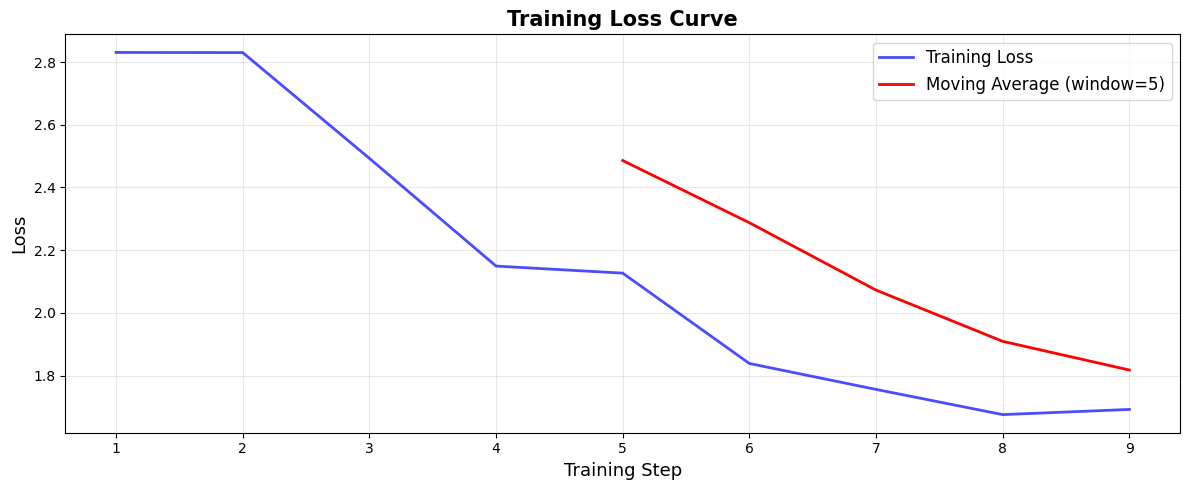


📊 Loss 통계:
   시작 Loss: 2.8307
   최종 Loss: 1.6921
   최소 Loss: 1.6756
   감소율: 40.2%

💡 Loss 곡선 분석 팁:
  - Loss가 꾸준히 감소 → 정상적으로 학습 중
  - Loss가 급격히 감소 후 정체 → 학습 완료
  - Loss가 증가 → 학습률 너무 높거나 과적합
  - Loss가 진동 → batch size 증가 필요 (grad_accum 올리기)


In [15]:
# 학습 로그 시각화
print("📊 학습 로그 분석")
print("=" * 60)

import matplotlib.pyplot as plt

# 학습 로그에서 loss 추출
log_history = trainer.state.log_history

train_losses = []
steps = []

for log in log_history:
    if 'loss' in log:
        train_losses.append(log['loss'])
        steps.append(log.get('step', len(steps)))

if train_losses:
    fig, ax = plt.subplots(figsize=(12, 5))
    
    ax.plot(steps, train_losses, 'b-', linewidth=2, alpha=0.7, label='Training Loss')
    
    # 이동 평균
    if len(train_losses) > 5:
        window = min(5, len(train_losses))
        import numpy as np
        moving_avg = np.convolve(train_losses, np.ones(window)/window, mode='valid')
        ax.plot(steps[window-1:], moving_avg, 'r-', linewidth=2, 
                label=f'Moving Average (window={window})')
    
    ax.set_xlabel('Training Step', fontsize=13)
    ax.set_ylabel('Loss', fontsize=13)
    ax.set_title('Training Loss Curve', fontsize=15, fontweight='bold')
    ax.legend(fontsize=12)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"\n📊 Loss 통계:")
    print(f"   시작 Loss: {train_losses[0]:.4f}")
    print(f"   최종 Loss: {train_losses[-1]:.4f}")
    print(f"   최소 Loss: {min(train_losses):.4f}")
    print(f"   감소율: {(train_losses[0] - train_losses[-1]) / train_losses[0] * 100:.1f}%")
else:
    print("⚠️ 학습 로그가 없습니다.")

print("\n💡 Loss 곡선 분석 팁:")
print("  - Loss가 꾸준히 감소 → 정상적으로 학습 중")
print("  - Loss가 급격히 감소 후 정체 → 학습 완료")
print("  - Loss가 증가 → 학습률 너무 높거나 과적합")
print("  - Loss가 진동 → batch size 증가 필요 (grad_accum 올리기)")

---
## 📝 9. 정리 및 핵심 요약

### 🎯 이번 세션에서 배운 핵심 개념

| # | 개념 | 핵심 내용 |
|---|------|----------|
| 1️⃣ | **NTP** | LLM은 다음 토큰 예측으로 학습 |
| 2️⃣ | **Causal LM** | 이전 토큰만 참조 (단방향) |
| 3️⃣ | **Trainer API** | TrainingArguments + Trainer |
| 4️⃣ | **SFTTrainer** | SFT 전용 (데이터 포맷팅 자동) |
| 5️⃣ | **LoRA SFT** | 전체의 ~1% 파라미터만 학습 |
| 6️⃣ | **Before/After** | 파인튜닝 효과 정성적 평가 |
| 7️⃣ | **Loss 분석** | 학습 곡선으로 학습 상태 판단 |

### 🔑 RTX 4060 SFT 요약 설정

```python
# 모델: Qwen2.5-1.5B-Instruct + LoRA
LoraConfig(r=16, lora_alpha=32, lora_dropout=0.05)

# 학습 설정 (소량 페르소나 데이터 암기용)
SFTConfig(
    per_device_train_batch_size=1,
    gradient_accumulation_steps=1,   # 데이터 적을 땐 작게 → 스텝 수 확보
    learning_rate=3e-4,
    num_train_epochs=15,
    bf16=True,
    max_length=1024,
    gradient_checkpointing=True,
)
```

> 💡 **학습이 안 될 때 체크리스트**
> - effective batch(=batch×grad_accum)가 데이터 수 대비 너무 크지 않은가? → epoch당 스텝이 한 자리면 거의 학습 안 됨
> - loss가 충분히(예: 0.3 이하) 내려갔는가? → 안 내려갔으면 epoch/lr 상향
> - LoRA target_modules / use_cache=False 설정이 맞는가?

### 📚 다음 세션 예고
- **Session 15**: Continuous Pretraining (지속 사전학습)

In [16]:
# 메모리 정리
print("🧹 메모리 정리")
print("=" * 60)

del model, trainer
gc.collect()
torch.cuda.empty_cache()
print_gpu_memory("정리 후")

print(f"\n✅ Session 14 완료!")
print(f"📁 저장된 파일: {OUTPUT_DIR}")
print(f"📚 다음 세션(Session 15): Continuous Pretraining (지속 사전학습)")
print(f"\n💡 이번 세션의 핵심:")
print(f"   1. LLM은 NTP로 학습 → SFT도 NTP 기반")
print(f"   2. LoRA로 1% 파라미터만 학습 → VRAM 절약")
print(f"   3. SFTTrainer로 간편하게 파인튜닝 가능")
print(f"   4. 데이터 품질과 양이 성능의 핵심!")

🧹 메모리 정리
[정리 후] GPU: 0.0GB / 7.6GB

✅ Session 14 완료!
📁 저장된 파일: /home/hpe/LLM_master_5parts/part2/output/qwen15b-lora-sft
📚 다음 세션(Session 15): Continuous Pretraining (지속 사전학습)

💡 이번 세션의 핵심:
   1. LLM은 NTP로 학습 → SFT도 NTP 기반
   2. LoRA로 1% 파라미터만 학습 → VRAM 절약
   3. SFTTrainer로 간편하게 파인튜닝 가능
   4. 데이터 품질과 양이 성능의 핵심!
